# MiniProject Wine

Citation Request:
  This dataset is public available for research. The details are described in [Cortez et al., 2009].
  Please include this citation if you plan to use this database:

  P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

  Available at: [@Elsevier] http://dx.doi.org/10.1016/j.dss.2009.05.016
                [Pre-press (pdf)] http://www3.dsi.uminho.pt/pcortez/winequality09.pdf
                [bib] http://www3.dsi.uminho.pt/pcortez/dss09.bib

1. Title: Wine Quality

2. Sources
   Created by: Paulo Cortez (Univ. Minho), Antonio Cerdeira, Fernando Almeida, Telmo Matos and Jose Reis (CVRVV) @ 2009
   
3. Past Usage:

  P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.
  Modeling wine preferences by data mining from physicochemical properties.
  In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

  In the above reference, two datasets were created, using red and white wine samples.
  The inputs include objective tests (e.g. PH values) and the output is based on sensory data
  (median of at least 3 evaluations made by wine experts). Each expert graded the wine quality
  between 0 (very bad) and 10 (very excellent). Several data mining methods were applied to model
  these datasets under a regression approach. The support vector machine model achieved the
  best results. Several metrics were computed: MAD, confusion matrix for a fixed error tolerance (T),
  etc. Also, we plot the relative importances of the input variables (as measured by a sensitivity
  analysis procedure).

4. Relevant Information:

   The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine.
   For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009].
   Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables
   are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

   These datasets can be viewed as classification or regression tasks.
   The classes are ordered and not balanced (e.g. there are munch more normal wines than
   excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent
   or poor wines. Also, we are not sure if all input variables are relevant. So
   it could be interesting to test feature selection methods.

5. Number of Instances: red wine - 1599; white wine - 4898.

6. Number of Attributes: 11 + output attribute
  
   Note: several of the attributes may be correlated, thus it makes sense to apply some sort of
   feature selection.

7. Attribute information:

   For more information, read [Cortez et al., 2009].

   Input variables (based on physicochemical tests):
   1 - fixed acidity
   2 - volatile acidity
   3 - citric acid
   4 - residual sugar
   5 - chlorides
   6 - free sulfur dioxide
   7 - total sulfur dioxide
   8 - density
   9 - pH
   10 - sulphates
   11 - alcohol
   Output variable (based on sensory data):
   12 - quality (score between 0 and 10)

8. Missing Attribute Values: None


In [1]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
wine_df = pd.read_csv("https://raw.githubusercontent.com/fisicangel/Min-project-2-wine/main/winequality-white.csv", sep=";")
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


**Check the shape of your data**

In [3]:
wine_df.shape

(4898, 12)

**Check for data types**

In [4]:
wine_df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


**Check for missing values**

In [5]:
wine_df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value.

In [6]:
wine_df.duplicated().sum()

np.int64(937)

In [7]:
#dropping rows with missing values and renaming the data frame
# Opcion 1
wine_df.drop_duplicates(inplace=True)
display(wine_df.head())
display(wine_df.shape)
# Opcion 2
# df = wine_df.drop_duplicates()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


(3961, 12)

In [8]:
#wine_df.describe()
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3961 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         3961 non-null   float64
 1   volatile acidity      3961 non-null   float64
 2   citric acid           3961 non-null   float64
 3   residual sugar        3961 non-null   float64
 4   chlorides             3961 non-null   float64
 5   free sulfur dioxide   3961 non-null   float64
 6   total sulfur dioxide  3961 non-null   float64
 7   density               3961 non-null   float64
 8   pH                    3961 non-null   float64
 9   sulphates             3961 non-null   float64
 10  alcohol               3961 non-null   float64
 11  quality               3961 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 402.3 KB


**KNN**

K Nearest Neighbors is a distance based algorithm, and requeries all **input data to be numerical.**

Let's only select numerical columns as our features.

In [9]:
wine_df.keys()

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [10]:
#all columns are numerical
#Selecting the target
target = wine_df['quality']
features = wine_df.drop(columns = ["quality"])
display(features.head())
display(features.shape)
display(target.head())
display(target.shape)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6


(3961, 11)

,quality
0,6
1,6
2,6
3,6
6,6


(3961,)

And also lets define our target.

In [11]:
wine_df['quality'].value_counts()

,count
quality,
6,1788
5,1175
7,689
4,153
8,131
3,20
9,5


**Train Test Split**

Now that we have split the data into **features** and **target** variables and imported the **train_test_split** function, split X and y into X_train, X_test, y_train, and y_test. 80% of the data should be in the training set and 20% in the test set.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=0)

**Model Selection**

In this exercise we will be using **KNN** as our predictive model.

You need to choose between **Classificator** or **Regressor**. Take into consideration target variable to decide.

Initialize a KNN instance without setting any hyperparameter.

Fit the model to your data.

**NOW Let's improve our model applying Feature Engineering**

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler

NORMALIZATION

In [14]:
normalizer = MinMaxScaler()

In [15]:
normalizer.fit(X_train)

MinMaxScaler()

In [16]:
X_train_norm = normalizer.transform(X_train)

X_test_norm = normalizer.transform(X_test)

New arrays in X_train_norm and X_test_norm after normalization


In [17]:
X_train_norm

array([[0.25961538, 0.19459459, 0.18674699, ..., 0.45454545, 0.46511628,
        0.74193548],
       [0.31730769, 0.0972973 , 0.25903614, ..., 0.35454545, 0.39534884,
        0.59677419],
       [0.19230769, 0.28108108, 0.12650602, ..., 0.4       , 0.31395349,
        0.29032258],
       ...,
       [0.24038462, 0.35675676, 0.18072289, ..., 0.73636364, 0.6627907 ,
        0.59677419],
       [0.45192308, 0.12972973, 0.24096386, ..., 0.25454545, 0.15116279,
        0.40322581],
       [0.27884615, 0.16216216, 0.19879518, ..., 0.35454545, 0.34883721,
        0.33870968]])

In [18]:
X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns,index=X_train.index)
X_train_norm.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3263,0.259615,0.194595,0.186747,0.046012,0.048193,0.115385,0.192575,0.060729,0.454545,0.465116,0.741935
3048,0.317308,0.097297,0.259036,0.010736,0.027108,0.104895,0.285383,0.068633,0.354545,0.395349,0.596774
4612,0.192308,0.281081,0.126506,0.101227,0.081325,0.157343,0.317865,0.140736,0.400000,0.313953,0.290323
853,0.375000,0.281081,0.349398,0.161043,0.075301,0.132867,0.329466,0.206092,0.309091,0.313953,0.096774
2571,0.307692,0.086486,0.192771,0.007669,0.054217,0.090909,0.164733,0.050318,0.463636,0.162791,0.661290


In [19]:
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns, index=X_test.index)
X_test_norm.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1509,0.394231,0.129730,0.295181,0.015337,0.117470,0.041958,0.313225,0.113553,0.400000,0.290698,0.403226
2154,0.576923,0.918919,0.271084,0.122699,0.114458,0.108392,0.412993,0.236939,0.363636,0.430233,0.354839
1237,0.336538,0.172973,0.234940,0.046012,0.030120,0.111888,0.248260,0.109697,0.409091,0.337209,0.467742
294,0.509615,0.551351,0.228916,0.015337,0.156627,0.108392,0.401392,0.186813,0.463636,0.186047,0.080645
4503,0.192308,0.572973,0.006024,0.119632,0.081325,0.097902,0.220418,0.073067,0.490909,0.581395,0.975806


REGRESSION MODEL AFTER NORMALIZATION


In [21]:
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_norm, y_train)

KNeighborsRegressor(n_neighbors=10)

In [26]:
print(f"The R2 of the regression model is {knn.score(X_test_norm, y_test)*100: .2f}%")

The R2 of the regression model is  27.02%


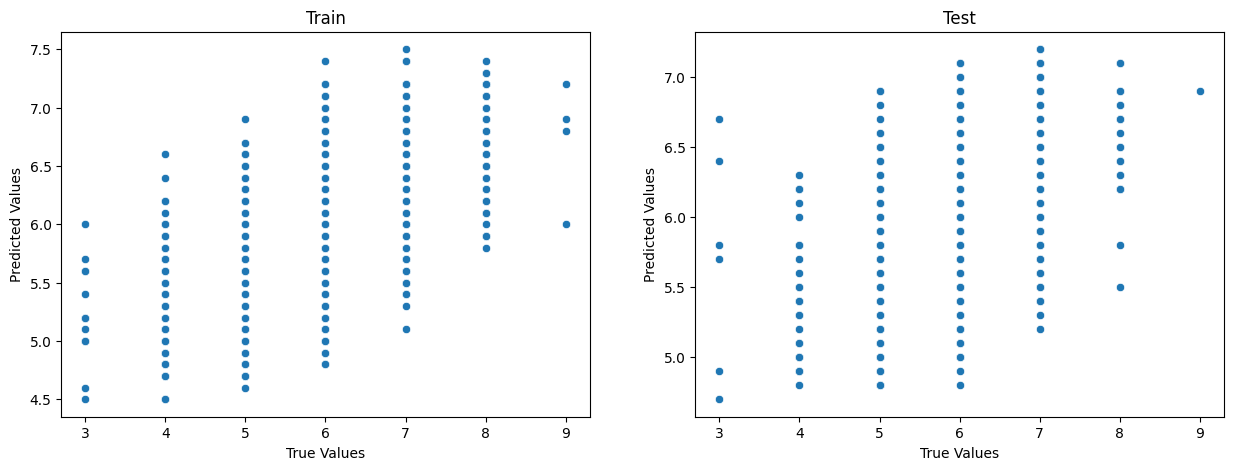

In [25]:
y_test_pred = knn.predict(X_test_norm)
y_train_pred = knn.predict(X_train_norm)

fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.scatterplot(x=y_train, y=y_train_pred, ax=axes[0])
sns.scatterplot(x=y_test, y=y_test_pred, ax=axes[1])
axes[0].set_title("Train")
axes[1].set_title("Test")
axes[0].set_xlabel("True Values")
axes[1].set_xlabel("True Values")
axes[0].set_ylabel("Predicted Values")
axes[1].set_ylabel("Predicted Values")
plt.show()

OBSERVING THE CORRELATION


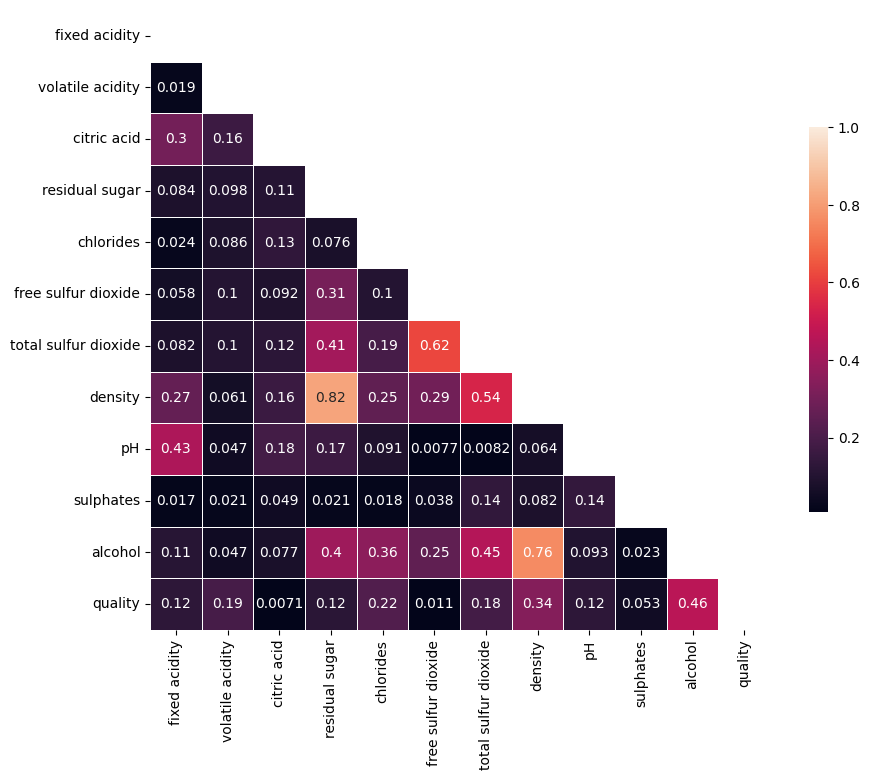

In [23]:
corr=np.abs(wine_df.corr())

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()